In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd



df = pd.read_csv('/content/drive/My Drive/2024_public_lar_csv.csv',)
df.head()

/tmp/ipython-input-2929043623.py:5: DtypeWarning: Columns (5,22,23,24,26,27,28,29,30,31,32,33,38,43,44,46,77,78,79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/2024_public_lar_csv.csv',)


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,WWB2V0FCW3A0EE3ZJN75,14860,CT,9190.0,9190210701,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,5877,80.84,146500,40.0,554,1715,67
1,2024,WWB2V0FCW3A0EE3ZJN75,35300,CT,9170.0,9170194101,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2045,6.26,116200,132.0,834,1455,59
2,2024,WWB2V0FCW3A0EE3ZJN75,99999,PA,42107.0,42107000700,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3364,12.13,81400,107.0,1338,1974,0
3,2024,WWB2V0FCW3A0EE3ZJN75,29540,PA,42071.0,42071014501,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5221,7.03,106700,107.0,1600,1891,34
4,2024,WWB2V0FCW3A0EE3ZJN75,99999,PA,42057.0,42057960300,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4692,5.58,81400,112.0,1514,2130,41


In [4]:
df.columns.tolist()

['activity_year',
 'lei',
 'derived_msa_md',
 'state_code',
 'county_code',
 'census_tract',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'action_taken',
 'purchaser_type',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open_end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'combined_loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'total_loan_costs',
 'total_points_and_fees',
 'origination_charges',
 'discount_points',
 'lender_credits',
 'loan_term',
 'prepayment_penalty_term',
 'intro_rate_period',
 'negative_amortization',
 'interest_only_payment',
 'balloon_payment',
 'other_nonamortizing_features',
 'property_value',
 'construction_method',
 'occupancy_type',
 'manufactured_home_secured_property_type',
 'manufactured_home_land_property_interest',
 'total_units',
 'multifamily_affordable_units',
 'in

In [5]:
cols_keep = [
    "loan_amount", "interest_rate", "loan_term", "loan_type", "loan_purpose",
    "lien_status", "rate_spread", "occupancy_type", "property_value",
    "income", "debt_to_income_ratio", "state_code", "county_code",
    "derived_msa_md", "action_taken"
]

df_clean = df[cols_keep].copy()

# quick check for missing values
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12229298 entries, 0 to 12229297
Data columns (total 15 columns):
 #   Column                Dtype  
---  ------                -----  
 0   loan_amount           int64  
 1   interest_rate         object 
 2   loan_term             object 
 3   loan_type             int64  
 4   loan_purpose          int64  
 5   lien_status           int64  
 6   rate_spread           object 
 7   occupancy_type        int64  
 8   property_value        object 
 9   income                float64
 10  debt_to_income_ratio  object 
 11  state_code            object 
 12  county_code           float64
 13  derived_msa_md        int64  
 14  action_taken          int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 1.4+ GB


,loan_amount,interest_rate,loan_term,loan_type,loan_purpose,lien_status,rate_spread,occupancy_type,property_value,income,debt_to_income_ratio,state_code,county_code,derived_msa_md,action_taken
0,105000,NaN,360,1,31,2,NaN,1,455000.0,86.0,50%-60%,CT,9190.0,14860,3
1,85000,12.59,360,1,2,2,4.31,1,695000.0,124.0,42,CT,9170.0,35300,1
2,25000,NaN,360,1,2,1,NaN,1,85000.0,NaN,NaN,PA,42107.0,99999,3
3,125000,9.34,360,1,2,2,1.17,1,865000.0,113.0,47,PA,42071.0,29540,1
4,55000,10.09,360,1,31,1,1.99,1,225000.0,34.0,20%-<30%,PA,42057.0,99999,1


In [6]:
# Step 4 – Filter & clean
df_filtered = df_clean[
    (df_clean["action_taken"] == 1) &     # originated
    (df_clean["loan_purpose"] == 1) &     # home purchase
    (df_clean["lien_status"] == 1) &      # first lien
    (df_clean["occupancy_type"] == 1)     # owner-occupied
].copy()

# Convert selected object columns to numeric, coercing errors to NaN
cols_to_num = ["interest_rate", "loan_term", "property_value", "debt_to_income_ratio", "rate_spread"]
for c in cols_to_num:
    df_filtered[c] = pd.to_numeric(df_filtered[c], errors="coerce")

# drop rows missing critical financial fields
df_filtered = df_filtered.dropna(subset=["loan_amount","interest_rate","loan_term","property_value"])

print("rows after filtering:", len(df_filtered))
df_filtered.head()

rows after filtering: 2882057


,loan_amount,interest_rate,loan_term,loan_type,loan_purpose,lien_status,rate_spread,occupancy_type,property_value,income,debt_to_income_ratio,state_code,county_code,derived_msa_md,action_taken
197,25000,11.29,360.0,1,1,1,3.15,1,315000.0,25.0,NaN,MD,24005.0,12580,1
210,145000,9.49,360.0,1,1,1,1.39,1,265000.0,52.0,NaN,NY,36029.0,15380,1
223,475000,10.19,360.0,1,1,1,2.09,1,555000.0,236.0,36.0,NY,36055.0,40380,1
283,205000,8.84,360.0,1,1,1,0.56,1,285000.0,164.0,NaN,PA,42001.0,23900,1
292,365000,9.94,360.0,1,1,1,1.83,1,425000.0,144.0,41.0,PA,42015.0,99999,1


In [7]:
import numpy as np

# Copy only the key numeric columns
df_amort = df_filtered[["loan_amount","interest_rate","loan_term","property_value"]].copy()

# Convert annual rate to monthly decimal
r = (df_amort["interest_rate"] / 100) / 12
n = df_amort["loan_term"]

# Monthly payment
df_amort["monthly_payment"] = (r * df_amort["loan_amount"]) / (1 - (1 + r) ** (-n))

# Function to compute remaining balance after given years
def remaining_balance(L, r_month, n_months, k_years):
    k = k_years * 12
    return L * (1 + r_month) ** k - ((r_month * L) / (1 - (1 + r_month) ** (-n_months))) * (((1 + r_month) ** k - 1) / r_month)

# Compute balances after 2, 5, and 10 years
for yrs in [2,5,10]:
    df_amort[f"balance_after_{yrs}y"] = remaining_balance(df_amort["loan_amount"], r, n, yrs)
    df_amort[f"equity_after_{yrs}y"] = df_amort["property_value"] - df_amort[f"balance_after_{yrs}y"]
    df_amort[f"equity_pct_{yrs}y"] = (df_amort[f"equity_after_{yrs}y"] / df_amort["property_value"]) * 100

# Basic summary: median equity % after 2,5,10 years
equity_summary = df_amort[[f"equity_pct_{y}y" for y in [2,5,10]]].describe(percentiles=[0.25,0.5,0.75]).T
print(equity_summary)

                    count       mean        std          min        25%  \
equity_pct_2y   2881031.0  17.581159  20.778024 -9560.522625   5.359818   
equity_pct_5y   2881031.0  21.688973  31.985216 -9140.386904   9.397039   
equity_pct_10y  2881031.0  30.667112  69.151259 -8239.533574  18.014030   

                      50%        75%           max  
equity_pct_2y   11.682163  22.950863   2816.711644  
equity_pct_5y   15.360671  26.359364   7869.111786  
equity_pct_10y  23.388908  33.747285  20484.497890  


In [8]:
from scipy import stats

eq2 = df_amort["equity_pct_2y"].dropna()
eq5 = df_amort["equity_pct_5y"].dropna()
eq10 = df_amort["equity_pct_10y"].dropna()

# paired t-tests
t25, p25 = stats.ttest_rel(eq2, eq5)
t510, p510 = stats.ttest_rel(eq5, eq10)
t210, p210 = stats.ttest_rel(eq2, eq10)

print(f"2y vs 5y:   t={t25:.2f},  p={p25:.3e}")
print(f"5y vs 10y:  t={t510:.2f}, p={p510:.3e}")
print(f"2y vs 10y:  t={t210:.2f}, p={p210:.3e}")

2y vs 5y:   t=-406.45,  p=0.000e+00
5y vs 10y:  t=-374.46, p=0.000e+00
2y vs 10y:  t=-384.02, p=0.000e+00


In [9]:
# Step 7 – Simulate sale outcomes
TXN_COST = 0.08
APPRECIATION_RATES = [0.00, 0.02, 0.04, 0.06]
YEARS = [2, 5, 10]

for g in APPRECIATION_RATES:
    for y in YEARS:
        sale_price = df_amort["property_value"] * ((1 + g) ** y)
        net_proceeds = sale_price * (1 - TXN_COST) - df_amort[f"balance_after_{y}y"]
        df_amort[f"net_{int(g*100)}pct_{y}y"] = net_proceeds

# Probability of negative proceeds by year & appreciation rate
import pandas as pd
summary_rows = []
for g in APPRECIATION_RATES:
    for y in YEARS:
        col = f"net_{int(g*100)}pct_{y}y"
        prob_neg = (df_amort[col] < 0).mean()
        med_gain = df_amort[col].median()
        summary_rows.append({
            "AppreciationRate": f"{int(g*100)}%",
            "YearsHeld": y,
            "Prob_Negative": round(prob_neg*100,2),
            "Median_NetProceeds": round(med_gain,2)
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

   AppreciationRate  YearsHeld  Prob_Negative  Median_NetProceeds
0                0%          2          41.20            11245.89
1                0%          5          17.32            24189.60
2                0%         10           0.15            58216.96
3                2%          2          18.84            23821.39
4                2%          5           0.14            63878.82
5                2%         10           0.02           139122.66
6                4%          2           2.38            38940.39
7                4%          5           0.04           105546.82
8                4%         10           0.01           233821.48
9                6%          2           0.27            55138.80
10               6%          5           0.03           149513.53
11               6%         10           0.01           344041.31


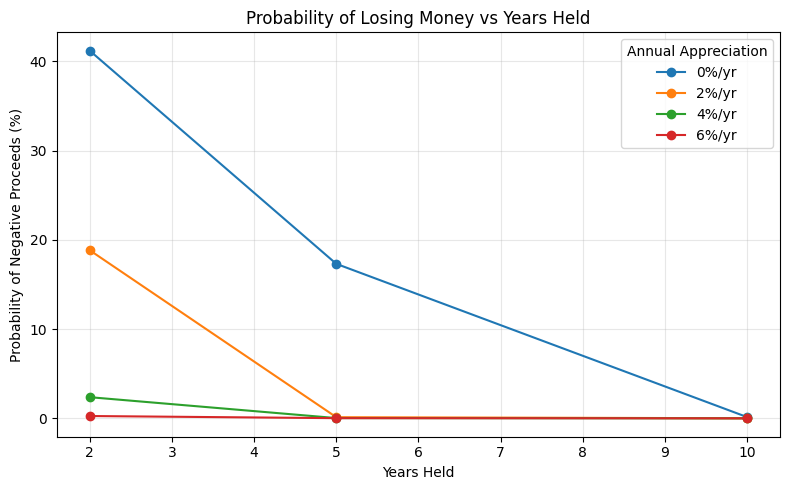

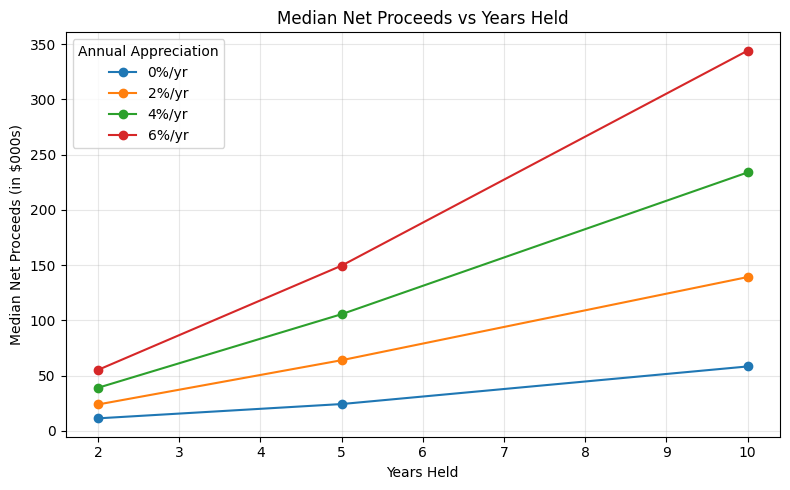

In [10]:
import matplotlib.pyplot as plt

# make sure summary_df exists
summary_df["YearsHeld"] = summary_df["YearsHeld"].astype(int)
summary_df["Prob_Negative"] = summary_df["Prob_Negative"].astype(float)
summary_df["Median_NetProceeds"] = summary_df["Median_NetProceeds"].astype(float)

# 1️⃣ Probability of Negative Proceeds
plt.figure(figsize=(8,5))
for g in summary_df["AppreciationRate"].unique():
    sub = summary_df[summary_df["AppreciationRate"]==g].sort_values("YearsHeld")
    plt.plot(sub["YearsHeld"], sub["Prob_Negative"], marker="o", label=f"{g}/yr")

plt.title("Probability of Losing Money vs Years Held")
plt.xlabel("Years Held")
plt.ylabel("Probability of Negative Proceeds (%)")
plt.legend(title="Annual Appreciation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2️⃣ Median Net Proceeds
plt.figure(figsize=(8,5))
for g in summary_df["AppreciationRate"].unique():
    sub = summary_df[summary_df["AppreciationRate"]==g].sort_values("YearsHeld")
    plt.plot(sub["YearsHeld"], sub["Median_NetProceeds"]/1000, marker="o", label=f"{g}/yr")

plt.title("Median Net Proceeds vs Years Held")
plt.xlabel("Years Held")
plt.ylabel("Median Net Proceeds (in $000s)")
plt.legend(title="Annual Appreciation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()